<a href="https://colab.research.google.com/github/edgi-govdata-archiving/EEW-ICE/blob/main/DWATER_ICE_Filtered.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Recreating a version of the EJSCREEN DWATER variable for ICE facs


### ICE facs

In [1]:
import pandas as pd
#This dataset is the result of a join between Deportation Data Project facility location and demographic data, and EJScreen: https://colab.research.google.com/drive/13Jt1lDr1OW4pIgbtGkOJipqw4qCzdE-e#scrollTo=aB_E8KcfKSRA
ddpfacs = pd.read_csv("https://docs.google.com/spreadsheets/d/12pdW_9cQ4ewZUqcGgwjKXemwBhuNM6C9nJdPMNwpGu4/export?format=csv", skiprows=[0]) # Saved copy to my own Drive and made it publicly viewable in order to do this

ddpfacs

,Unnamed: 0,detention_facility_code,name,address,city,county,county_fips_code,core_based_statistical_area,core_based_statistical_area_code,core_based_statistical_area_type,...,state.EJ.DISPARITY.drinking.supp,area_sqmi,row_id,index_right,DWATER,P_DWATER,P_D2_DWATER,P_D5_DWATER,ID,ST_ABBREV
0,0,IWAHOLD,AZ Removal Operation Coord Center (Arocc),"6335 South Downwind, Suite 104",Mesa,Maricopa,4013.0,"Phoenix-Mesa-Chandler, AZ",38060.0,Metro,...,50.3211,28.2743,0.0,6982.0,1.0,78.0,0.0,73.0,4.013523e+10,AZ
1,1,ABRXSPA,Abraxas Academy,1000 Academy Drive,Morgantown,Berks,42011.0,"Reading, PA",39740.0,Metro,...,50.0426,28.2743,1.0,182415.0,0.0,0.0,0.0,0.0,4.201101e+11,PA
2,2,ADAMSMS,Adams County Correctional Center,20 Hobo Forks Road,Natchez,Adams,28001.0,"Natchez, MS-LA",35020.0,Micro,...,0.0000,28.2743,2.0,120055.0,0.0,0.0,0.0,0.0,2.800100e+11,MS
3,3,ADDCOVT,Addison County Jail,35 Court Street,Middlebury,Addison,50001.0,NaN,NaN,NaN,...,2.9614,28.2743,3.0,221186.0,0.0,0.0,0.0,0.0,5.000196e+11,VT
4,4,ADLNTCA,Adelanto ICE Processing Center,10400 Rancho Road,Adelanto,San Bernardino,6071.0,"Riverside-San Bernardino-Ontario, CA",40140.0,Metro,...,0.0000,28.2743,4.0,28813.0,0.0,0.0,0.0,0.0,6.071009e+10,CA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,839,YORCOSC,York County Detention Center,1675 York Hwy #3-A,York,York,45091.0,"Charlotte-Concord-Gastonia, NC-SC",16740.0,Metro,...,100.5340,28.2743,705.0,195214.0,NaN,NaN,NaN,NaN,4.509106e+11,SC
840,840,YORCOPA,York County Prison,3401 Concord Road,York,York,42133.0,"York-Hanover, PA",49620.0,Metro,...,7.6823,28.2743,706.0,190768.0,0.0,0.0,0.0,0.0,4.213301e+11,PA
841,841,YRKHOLD,York Hold Room,1605 Clugston Road,York,York,42133.0,"York-Hanover, PA",49620.0,Metro,...,0.0000,28.2743,707.0,190751.0,0.0,0.0,0.0,0.0,4.213300e+11,PA
842,842,YUMHOLD,Yuma Hold Room,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
#assign boolean mask based on n_detained_possibly_under_18
ddpfacs['under_18'] = ddpfacs['n_detained_possibly_under_18'] > 0
ddpfacs['under_18_num'] = ddpfacs['under_18'].astype(int)
ddpfacs



#

,Unnamed: 0,detention_facility_code,name,address,city,county,county_fips_code,core_based_statistical_area,core_based_statistical_area_code,core_based_statistical_area_type,...,row_id,index_right,DWATER,P_DWATER,P_D2_DWATER,P_D5_DWATER,ID,ST_ABBREV,under_18,under_18_binary
0,0,IWAHOLD,AZ Removal Operation Coord Center (Arocc),"6335 South Downwind, Suite 104",Mesa,Maricopa,4013.0,"Phoenix-Mesa-Chandler, AZ",38060.0,Metro,...,0.0,6982.0,1.0,78.0,0.0,73.0,4.013523e+10,AZ,True,1
1,1,ABRXSPA,Abraxas Academy,1000 Academy Drive,Morgantown,Berks,42011.0,"Reading, PA",39740.0,Metro,...,1.0,182415.0,0.0,0.0,0.0,0.0,4.201101e+11,PA,True,1
2,2,ADAMSMS,Adams County Correctional Center,20 Hobo Forks Road,Natchez,Adams,28001.0,"Natchez, MS-LA",35020.0,Micro,...,2.0,120055.0,0.0,0.0,0.0,0.0,2.800100e+11,MS,False,0
3,3,ADDCOVT,Addison County Jail,35 Court Street,Middlebury,Addison,50001.0,NaN,NaN,NaN,...,3.0,221186.0,0.0,0.0,0.0,0.0,5.000196e+11,VT,False,0
4,4,ADLNTCA,Adelanto ICE Processing Center,10400 Rancho Road,Adelanto,San Bernardino,6071.0,"Riverside-San Bernardino-Ontario, CA",40140.0,Metro,...,4.0,28813.0,0.0,0.0,0.0,0.0,6.071009e+10,CA,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,839,YORCOSC,York County Detention Center,1675 York Hwy #3-A,York,York,45091.0,"Charlotte-Concord-Gastonia, NC-SC",16740.0,Metro,...,705.0,195214.0,NaN,NaN,NaN,NaN,4.509106e+11,SC,False,0
840,840,YORCOPA,York County Prison,3401 Concord Road,York,York,42133.0,"York-Hanover, PA",49620.0,Metro,...,706.0,190768.0,0.0,0.0,0.0,0.0,4.213301e+11,PA,False,0
841,841,YRKHOLD,York Hold Room,1605 Clugston Road,York,York,42133.0,"York-Hanover, PA",49620.0,Metro,...,707.0,190751.0,0.0,0.0,0.0,0.0,4.213300e+11,PA,True,1
842,842,YUMHOLD,Yuma Hold Room,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,1


### Compliance points data

In [3]:
import pandas as pd

url = "https://echo.epa.gov/files/echodownloads/SDWA_system_search_download.zip"

# Pandas downloads, unzips, and reads the CSV automatically
points = pd.read_csv(url, compression='zip')

points

/tmp/ipykernel_1146/3593941986.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  points = pd.read_csv(url, compression='zip')


,PWS_NAME,PWSID,CITIES_SERVED,STATE_CODE,ZIP_CODES_SERVED,COUNTIES_SERVED,EPA_REGION,REGISTRY_ID,INDIAN_COUNTRY,PWS_TYPE_CODE,...,SIGNIFICANT_DEFICIENCY_COUNT_ILS,SIG_DEF_COUNT_ILS_ACT,SDW_DATE_LAST_VISIT,SDW_DATE_LAST_VISIT_EPA,SDW_DATE_LAST_VISIT_STATE,SDW_DATE_LAST_VISIT_LOCAL,SITE_VISITS_5YR_ALL,SITE_VISITS_5YR_INSPECTIONS,SITE_VISITS_5YR_OTHER,WEB_DOCS
0,OLYMPIC VIEW ESTATES,WA5342421,NaN,WA,NaN,Island,10,110049825668,N,CWS,...,NaN,NaN,04/18/2024,NaN,04/18/2024,NaN,1,0,1.0,NaN
1,BLUE STONE INN,VA2165033,NaN,VA,NaN,Rockingham,3,110052978970,N,TNCWS,...,NaN,NaN,01/26/2022,NaN,01/26/2022,NaN,1,0,1.0,NaN
2,EDWARDS-KNOX CENTRAL SCHOOL,NY4421792,RUSSELL (T),NY,NaN,St. Lawrence,2,110041888259,N,NTNCWS,...,NaN,NaN,05/28/2025,NaN,10/07/2019,05/28/2025,2,0,2.0,NaN
3,QUAPAW TRIBE,OK2005812,NaN,OK,NaN,Ottawa,6,110011008033,N,CWS,...,NaN,NaN,02/26/2025,NaN,02/26/2025,NaN,4,2,2.0,NaN
4,CARL T HAYDEN VETERANS MEDICAL CENTER,AZ0407580,NaN,AZ,NaN,Maricopa,9,110072197061,N,NTNCWS,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434035,INDEPENDENT ORDER OF VIKINGS,IL0095992,NaN,IL,NaN,Winnebago,5,110051378683,N,TNCWS,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN
434036,COLONIAL MOBILE HOME PARK,AL0000478,NaN,AL,NaN,Dallas,4,110047727625,N,CWS,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN
434037,ROGERS ORCHARDS,CT1319133,NaN,CT,NaN,Hartford,1,110049948492,N,TNCWS,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN
434038,HIDDEN CREEK GOLF CLUB,FL6515254,ZEPHYRHILLS,FL,NaN,Pasco,4,110053914671,N,TNCWS,...,NaN,NaN,NaN,NaN,01/30/2008,NaN,0,0,NaN,NaN


In [4]:
# Get water system boundaries
# Written with help from Gemini

import os
import urllib.request
import zipfile

url = "https://github.com/USEPA/ORD_SAB_Model/raw/refs/heads/main/Version_History/PWS_Boundaries_Latest.zip"
extract_to = "./pws"
temp_zip = "PWS_Boundaries_Latest.zip"

# 1. Download the archive to a physical file
print("Downloading...")
urllib.request.urlretrieve(url, temp_zip)

# 2. Extract the file
print("Extracting...")
with zipfile.ZipFile(temp_zip, "r") as zip_ref:
    zip_ref.extractall(extract_to)

# 3. Clean up the downloaded .zip file
os.remove(temp_zip)
print("Done!")


Downloading...
Extracting...
Done!


In [5]:
import geopandas

cws = geopandas.read_file("pws/3_0/Service_Areas_V_3_0.gpkg")

cws

/usr/local/lib/python3.13/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'Service_Areas_V_3_0.gpkg': 'CWS' (default), 'T_NTNC'. Specify layer parameter to avoid this warning.
  result = read_func(


,Original_Data_Provider,Data_Provider_Type,Data_Source,PWSID,PWS_Name,Primacy_Agency,Pop_Cat_5,Population_Served_Count,Service_Connections_Count,Model_Method,...,Feature_Type,Method_Details,Verification_Status,Detailed_Facility_Report,Confirmed,PWSID_1,Shape_Length,Shape_Area,Date_Create,geometry
0,US EPA Office of Research and Development,Federal agency,,IA1103009,ALBERT CITY MUNI WATER SUPPLY,IA,"501-3,300",677.0,338.0,Random Forest,...,,,,https://echo.epa.gov/detailed-facility-report?...,,None,8439.583233,2.144797e+06,2024-06-06,"MULTIPOLYGON (((-94.95325 42.77116, -94.95325 ..."
1,US EPA Office of Research and Development,Federal agency,,IA1150030,MARATHON LIGHT & WATER DEPARTMENT,IA,<=500,230.0,120.0,Random Forest,...,,,,https://echo.epa.gov/detailed-facility-report?...,,None,7882.744094,2.905012e+06,2024-06-06,"MULTIPOLYGON (((-94.97816 42.85514, -94.97846 ..."
2,US EPA Office of Research and Development,Federal agency,,IA1175056,SIOUX RAPIDS WATER DEPARTMENT,IA,"501-3,300",920.0,373.0,Random Forest,...,,,,https://echo.epa.gov/detailed-facility-report?...,,None,12637.892945,3.471844e+06,2024-06-06,"MULTIPOLYGON (((-95.15328 42.88467, -95.15326 ..."
3,US EPA Office of Research and Development,Federal agency,,IA2109041,DICKENS WATER WORKS,IA,<=500,151.0,75.0,Random Forest,...,,,,https://echo.epa.gov/detailed-facility-report?...,,None,5576.325161,1.308007e+06,2024-06-06,"MULTIPOLYGON (((-95.02695 43.13076, -95.02701 ..."
4,US EPA Office of Research and Development,Federal agency,,IA2122067,FOSTORIA MUNICIPAL WATER SUPPLY,IA,<=500,233.0,133.0,Random Forest,...,,,,https://echo.epa.gov/detailed-facility-report?...,,None,6618.601702,1.983564e+06,2024-06-06,"MULTIPOLYGON (((-95.15316 43.23445, -95.15179 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44651,Alaska Division of Community and Regional Affairs,State,https://www.arcgis.com/home/item.html?id=12026...,AK2360256,FT. YUKON PUBLIC WATER SYSTEM,AK,"501-3,300",665.0,200.0,None,...,Water Utility Service Area,None,None,https://echo.epa.gov/detailed-facility-report?...,None,None,35739.441987,5.184036e+07,2025-07-14,"MULTIPOLYGON (((-145.24721 66.55218, -145.2472..."
44652,Alaska Division of Community and Regional Affairs,State,https://www.arcgis.com/home/item.html?id=12026...,AK2360272,GALENA WTP1 - CITY,AK,<=500,490.0,98.0,None,...,Water Utility Service Area,None,None,https://echo.epa.gov/detailed-facility-report?...,None,None,84066.068422,3.358993e+08,2025-07-14,"MULTIPOLYGON (((-156.72784 64.71555, -156.7278..."
44653,None,None,https://www.arcgis.com/home/item.html?id=12026...,AK2370780,FT. GREELY - MAIN POST,AK,"501-3,300",1257.0,119.0,None,...,None,None,None,https://echo.epa.gov/detailed-facility-report?...,None,None,60684.740217,1.501481e+08,None,"MULTIPOLYGON (((-145.77235 63.93964, -145.7723..."
44654,Alaska Division of Community and Regional Affairs,State,https://www.arcgis.com/home/item.html?id=12026...,AK2380214,GULKANA VILLAGE,AK,<=500,90.0,33.0,None,...,Water Utility Service Area,None,None,https://echo.epa.gov/detailed-facility-report?...,None,None,9344.307006,3.454643e+06,2025-07-14,"MULTIPOLYGON (((-145.36714 62.26426, -145.3671..."


In [6]:
# Associate with compliance points
cws = pd.merge(cws, points, on="PWSID", how="left")

cws

,Original_Data_Provider,Data_Provider_Type,Data_Source,PWSID,PWS_Name,Primacy_Agency,Pop_Cat_5,Population_Served_Count,Service_Connections_Count,Model_Method,...,SIGNIFICANT_DEFICIENCY_COUNT_ILS,SIG_DEF_COUNT_ILS_ACT,SDW_DATE_LAST_VISIT,SDW_DATE_LAST_VISIT_EPA,SDW_DATE_LAST_VISIT_STATE,SDW_DATE_LAST_VISIT_LOCAL,SITE_VISITS_5YR_ALL,SITE_VISITS_5YR_INSPECTIONS,SITE_VISITS_5YR_OTHER,WEB_DOCS
0,US EPA Office of Research and Development,Federal agency,,IA1103009,ALBERT CITY MUNI WATER SUPPLY,IA,"501-3,300",677.0,338.0,Random Forest,...,NaN,NaN,04/25/2024,NaN,04/25/2024,NaN,2.0,0.0,2.0,NaN
1,US EPA Office of Research and Development,Federal agency,,IA1150030,MARATHON LIGHT & WATER DEPARTMENT,IA,<=500,230.0,120.0,Random Forest,...,1.0,1.0,12/16/2024,NaN,12/16/2024,NaN,2.0,0.0,2.0,NaN
2,US EPA Office of Research and Development,Federal agency,,IA1175056,SIOUX RAPIDS WATER DEPARTMENT,IA,"501-3,300",920.0,373.0,Random Forest,...,1.0,1.0,05/09/2025,NaN,05/09/2025,NaN,2.0,0.0,2.0,NaN
3,US EPA Office of Research and Development,Federal agency,,IA2109041,DICKENS WATER WORKS,IA,<=500,151.0,75.0,Random Forest,...,NaN,NaN,08/02/2023,NaN,08/02/2023,NaN,1.0,0.0,1.0,NaN
4,US EPA Office of Research and Development,Federal agency,,IA2122067,FOSTORIA MUNICIPAL WATER SUPPLY,IA,<=500,233.0,133.0,Random Forest,...,NaN,NaN,08/02/2023,NaN,08/02/2023,NaN,1.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44651,Alaska Division of Community and Regional Affairs,State,https://www.arcgis.com/home/item.html?id=12026...,AK2360256,FT. YUKON PUBLIC WATER SYSTEM,AK,"501-3,300",665.0,200.0,None,...,2.0,2.0,06/24/2025,NaN,06/24/2025,NaN,2.0,0.0,2.0,NaN
44652,Alaska Division of Community and Regional Affairs,State,https://www.arcgis.com/home/item.html?id=12026...,AK2360272,GALENA WTP1 - CITY,AK,<=500,490.0,98.0,None,...,2.0,2.0,12/18/2023,NaN,12/18/2023,08/17/2017,1.0,0.0,1.0,NaN
44653,None,None,https://www.arcgis.com/home/item.html?id=12026...,AK2370780,FT. GREELY - MAIN POST,AK,"501-3,300",1257.0,119.0,None,...,NaN,NaN,05/27/2025,NaN,05/27/2025,06/17/2022,2.0,0.0,4.0,NaN
44654,Alaska Division of Community and Regional Affairs,State,https://www.arcgis.com/home/item.html?id=12026...,AK2380214,GULKANA VILLAGE,AK,<=500,90.0,33.0,None,...,1.0,1.0,04/21/2025,NaN,04/21/2025,08/03/2016,2.0,0.0,2.0,NaN


In [7]:
# Investigate points system
# See: https://echo.epa.gov/help/facility-search/drinking-water-search-results-help
# Based on tech documentation ("The indicator reflects compliance performance for only the last 5-years (2019 Q4- 2023 Q4). Scores are only given to water systems for violations that have not been returned to compliance. ") I think we are dealing with the "vioremain" variable - "Sum of violation points that were not returned to compliance as of the latest quarterly refresh from the source system, which may lag by 3-6 months. Includes points that have received formal enforcement but have not returned to compliance."

cws['VIOREMAIN']

,VIOREMAIN
0,0.0
1,0.0
2,2.0
3,0.0
4,0.0
...,...
44651,15.0
44652,10.0
44653,0.0
44654,5.0


In [8]:
cws["VIOREMAIN"].describe()

,VIOREMAIN
count,44646.000000
mean,2.758702
std,14.831654
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,614.000000


### Analyze CWS and ICE facs together

In [9]:
# First, filter to mappable ICE facs :( lat/lng boundaries
this_type = "full" #"ice" # "full"
latlng = {"full": {"latitude": "latitude", "longitude": "longitude"}, "ice": {"latitude": "FAC_LAT", "longitude": "FAC_LONG"}}
mapicefacs = ddpfacs[~ddpfacs[latlng[this_type]["latitude"]].isna()] # Just check lat?
mapicefacs = geopandas.GeoDataFrame(mapicefacs, geometry=geopandas.points_from_xy(x=mapicefacs[latlng[this_type]["longitude"]], y=mapicefacs[latlng[this_type]["latitude"]], crs=4326)) # Guessing at CRS here
try:
  mapicefacs.drop(columns="index_right", inplace=True)
except KeyError:
  pass
mapicefacs

,Unnamed: 0,detention_facility_code,name,address,city,county,county_fips_code,core_based_statistical_area,core_based_statistical_area_code,core_based_statistical_area_type,...,area_sqmi,row_id,DWATER,P_DWATER,P_D2_DWATER,P_D5_DWATER,ID,ST_ABBREV,under_18,under_18_binary
0,0,IWAHOLD,AZ Removal Operation Coord Center (Arocc),"6335 South Downwind, Suite 104",Mesa,Maricopa,4013.0,"Phoenix-Mesa-Chandler, AZ",38060.0,Metro,...,28.2743,0.0,1.0,78.0,0.0,73.0,4.013523e+10,AZ,True,1
1,1,ABRXSPA,Abraxas Academy,1000 Academy Drive,Morgantown,Berks,42011.0,"Reading, PA",39740.0,Metro,...,28.2743,1.0,0.0,0.0,0.0,0.0,4.201101e+11,PA,True,1
2,2,ADAMSMS,Adams County Correctional Center,20 Hobo Forks Road,Natchez,Adams,28001.0,"Natchez, MS-LA",35020.0,Micro,...,28.2743,2.0,0.0,0.0,0.0,0.0,2.800100e+11,MS,False,0
3,3,ADDCOVT,Addison County Jail,35 Court Street,Middlebury,Addison,50001.0,NaN,NaN,NaN,...,28.2743,3.0,0.0,0.0,0.0,0.0,5.000196e+11,VT,False,0
4,4,ADLNTCA,Adelanto ICE Processing Center,10400 Rancho Road,Adelanto,San Bernardino,6071.0,"Riverside-San Bernardino-Ontario, CA",40140.0,Metro,...,28.2743,4.0,0.0,0.0,0.0,0.0,6.071009e+10,CA,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,838,YELLOMT,Yellowstone County Jail,3165 King Avenue East,Billings,Yellowstone,30111.0,"Billings, MT",13740.0,Metro,...,28.2743,704.0,0.0,0.0,0.0,0.0,3.011100e+11,MT,False,0
839,839,YORCOSC,York County Detention Center,1675 York Hwy #3-A,York,York,45091.0,"Charlotte-Concord-Gastonia, NC-SC",16740.0,Metro,...,28.2743,705.0,NaN,NaN,NaN,NaN,4.509106e+11,SC,False,0
840,840,YORCOPA,York County Prison,3401 Concord Road,York,York,42133.0,"York-Hanover, PA",49620.0,Metro,...,28.2743,706.0,0.0,0.0,0.0,0.0,4.213301e+11,PA,False,0
841,841,YRKHOLD,York Hold Room,1605 Clugston Road,York,York,42133.0,"York-Hanover, PA",49620.0,Metro,...,28.2743,707.0,0.0,0.0,0.0,0.0,4.213300e+11,PA,True,1


In [10]:
# Join ICE facs to CWS boundaries
# Project
cws_w_ice = geopandas.sjoin(cws.to_crs(5070), mapicefacs.to_crs(5070), how="right") # how = right ensures that each ICE fac info is preserved, enabling compilation of demographic info per CWS
cws_w_ice

,index_left,Original_Data_Provider,Data_Provider_Type,Data_Source,PWSID,PWS_Name,Primacy_Agency,Pop_Cat_5,Population_Served_Count,Service_Connections_Count,...,area_sqmi,row_id,DWATER,P_DWATER,P_D2_DWATER,P_D5_DWATER,ID,ST_ABBREV,under_18,under_18_binary
0,6534.0,Arizona Department of Water Resources,State Agency,https://gisdata2016-11-18t150447874z-azwater.o...,AZ0407095,MESA CITY OF,AZ,">100,000",466000.0,142500.0,...,28.2743,0.0,1.0,78.0,0.0,73.0,4.013523e+10,AZ,True,1
1,32841.0,PA Department of Environmental Protection,State Agency,https://newdata-padep-1.opendata.arcgis.com/ma...,PA3060127,ABRAXAS ACADEMY,PA,<=500,156.0,1.0,...,28.2743,1.0,0.0,0.0,0.0,0.0,4.201101e+11,PA,True,1
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.2743,2.0,0.0,0.0,0.0,0.0,2.800100e+11,MS,False,0
3,42230.0,Vermont,State Agency,https://anrmaps.vermont.gov/arcgis/rest/servic...,VT0005004,MIDDLEBURY WATER DEPT,VT,"3,301-10,000",9379.0,2368.0,...,28.2743,3.0,0.0,0.0,0.0,0.0,5.000196e+11,VT,False,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.2743,4.0,0.0,0.0,0.0,0.0,6.071009e+10,CA,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,9704.0,,,,MT0000153,BILLINGS CITY OF,MT,">100,000",114000.0,32872.0,...,28.2743,704.0,0.0,0.0,0.0,0.0,3.011100e+11,MT,False,0
839,41324.0,York County,County,https://opendata-yorkcosc.hub.arcgis.com/datas...,SC4610001,YORK CITY OF (SC4610001),SC,"3,301-10,000",8700.0,4103.0,...,28.2743,705.0,NaN,NaN,NaN,NaN,4.509106e+11,SC,False,0
840,31411.0,PA Department of Environmental Protection,State Agency,https://newdata-padep-1.opendata.arcgis.com/ma...,PA7670100,YORK WATER CO,PA,">100,000",206762.0,68414.0,...,28.2743,706.0,0.0,0.0,0.0,0.0,4.213301e+11,PA,False,0
841,31411.0,PA Department of Environmental Protection,State Agency,https://newdata-padep-1.opendata.arcgis.com/ma...,PA7670100,YORK WATER CO,PA,">100,000",206762.0,68414.0,...,28.2743,707.0,0.0,0.0,0.0,0.0,4.213300e+11,PA,True,1


In [11]:
# Clean up
# Drop NAN PWSIDs, these are probably where a mappable ICE fac isn't served by a CWS
cws_w_ice = cws_w_ice[~cws_w_ice["PWSID"].isna()]
cws_w_ice

,index_left,Original_Data_Provider,Data_Provider_Type,Data_Source,PWSID,PWS_Name,Primacy_Agency,Pop_Cat_5,Population_Served_Count,Service_Connections_Count,...,area_sqmi,row_id,DWATER,P_DWATER,P_D2_DWATER,P_D5_DWATER,ID,ST_ABBREV,under_18,under_18_binary
0,6534.0,Arizona Department of Water Resources,State Agency,https://gisdata2016-11-18t150447874z-azwater.o...,AZ0407095,MESA CITY OF,AZ,">100,000",466000.0,142500.0,...,28.2743,0.0,1.0,78.0,0.0,73.0,4.013523e+10,AZ,True,1
1,32841.0,PA Department of Environmental Protection,State Agency,https://newdata-padep-1.opendata.arcgis.com/ma...,PA3060127,ABRAXAS ACADEMY,PA,<=500,156.0,1.0,...,28.2743,1.0,0.0,0.0,0.0,0.0,4.201101e+11,PA,True,1
3,42230.0,Vermont,State Agency,https://anrmaps.vermont.gov/arcgis/rest/servic...,VT0005004,MIDDLEBURY WATER DEPT,VT,"3,301-10,000",9379.0,2368.0,...,28.2743,3.0,0.0,0.0,0.0,0.0,5.000196e+11,VT,False,0
5,5724.0,Division of Drinking Water of the California W...,State Agency,https://gis.data.ca.gov/datasets/fbba842bf1344...,CA1510003,CWS - BAKERSFIELD,CA,">100,000",267881.0,65415.0,...,28.2743,5.0,0.0,0.0,0.0,0.0,6.029002e+10,CA,False,0
6,586.0,US EPA Office of Research and Development,Federal agency,,HI0000331,HNL-WINDWARD-PEARL HARBOR,HI,">100,000",631389.0,106491.0,...,28.2743,6.0,0.0,0.0,0.0,0.0,1.500301e+11,HI,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,9704.0,,,,MT0000153,BILLINGS CITY OF,MT,">100,000",114000.0,32872.0,...,28.2743,704.0,0.0,0.0,0.0,0.0,3.011100e+11,MT,False,0
839,41324.0,York County,County,https://opendata-yorkcosc.hub.arcgis.com/datas...,SC4610001,YORK CITY OF (SC4610001),SC,"3,301-10,000",8700.0,4103.0,...,28.2743,705.0,NaN,NaN,NaN,NaN,4.509106e+11,SC,False,0
840,31411.0,PA Department of Environmental Protection,State Agency,https://newdata-padep-1.opendata.arcgis.com/ma...,PA7670100,YORK WATER CO,PA,">100,000",206762.0,68414.0,...,28.2743,706.0,0.0,0.0,0.0,0.0,4.213301e+11,PA,False,0
841,31411.0,PA Department of Environmental Protection,State Agency,https://newdata-padep-1.opendata.arcgis.com/ma...,PA7670100,YORK WATER CO,PA,">100,000",206762.0,68414.0,...,28.2743,707.0,0.0,0.0,0.0,0.0,4.213300e+11,PA,True,1


In [12]:
# Unique number of CWS serving ICE facs
len(cws_w_ice["PWSID"].unique())

427

In [13]:
# Group by, summarizing ICE detention facts
# For now, just doing n_detained but this could be greatly expanded - CC added "n_detained_possibly_under_18" 8/24/26
attributes = {"full": {"n_detained":"max", "n_detained_possibly_under_18":"max", "days_with_detentions_daily_last_year":"max"}, "ice": {}} # no attrbutes for ICE.gov

"""
    "n_detained": "max", # sum n_detained across ICE facs in a given CWS (Maximum number of distinct individuals detained at the facility on any given day within the time-frame of the dataset (Jan 20th 2025-)) SUM may not be the right measure....
    "days_with_detentions_daily_last_year": "max", # getting a sense of whether worst/long-term facs served
"""

summary = cws_w_ice.groupby(by="PWSID")[["VIOREMAIN"] + list(attributes[this_type].keys())].agg({"VIOREMAIN": "first"} | attributes[this_type]) # compliance points for the CWS
summary

,VIOREMAIN,n_detained,n_detained_possibly_under_18,days_with_detentions_daily_last_year
PWSID,,,,
090400051,7.0,10.0,0.0,245.0
090415013,0.0,10.0,0.0,245.0
AK2110342,0.0,1.0,0.0,16.0
AK2120232,0.0,1.0,0.0,3.0
AK2210906,0.0,43.0,2.0,296.0
...,...,...,...,...
WV3302364,19.0,23.0,0.0,38.0
WV3302609,5.0,86.0,0.0,314.0
WY5600011,0.0,17.0,0.0,177.0


<Axes: xlabel='days_with_detentions_daily_last_year', ylabel='VIOREMAIN'>

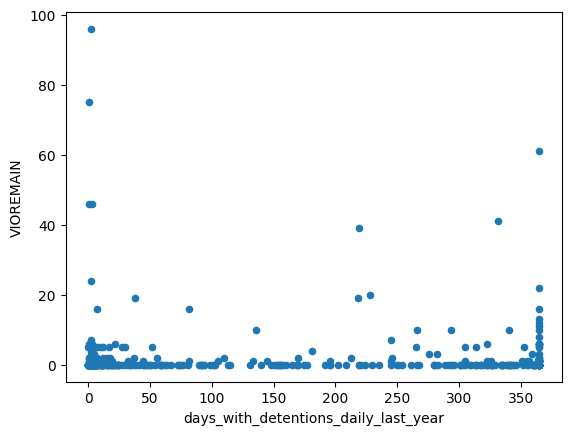

In [14]:
# Plot demo data against compliance points
summary.plot(kind="scatter", x="days_with_detentions_daily_last_year", y="VIOREMAIN")

<Axes: xlabel='n_detained_possibly_under_18', ylabel='VIOREMAIN'>

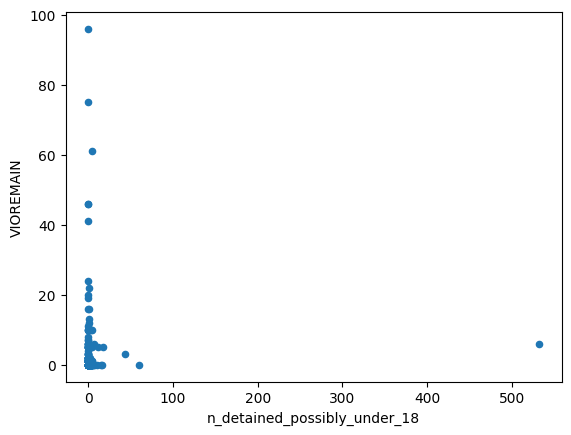

In [16]:
summary.plot(kind="scatter", x="n_detained_possibly_under_18", y="VIOREMAIN")

In [25]:
import scipy.stats as stats

# Perform one-way ANOVA - will ultimately need to test with only ~142 dedicated detentional facs, but this is a test

group_1 = cws_w_ice[
    cws_w_ice["under_18_num"] == 1
]["VIOREMAIN"].dropna()

group_2 = cws_w_ice[
    cws_w_ice["under_18_num"] == 0
]["VIOREMAIN"].dropna()

f_statistic, p_value = stats.f_oneway(group_1, group_2)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 2.884359743129094
p-value: 0.08995351313946069


In [26]:
# National comparison: how do CWS with ICE facs stack up against ALL CWS in terms of compliance points

cws_wo_ice = cws[~cws["PWSID"].isin(list(cws_w_ice["PWSID"].unique()))]
print(cws_wo_ice["VIOREMAIN"].describe())
print(summary["VIOREMAIN"].describe())

count    44220.000000
mean         2.764925
std         14.880708
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        614.000000
Name: VIOREMAIN, dtype: float64
count    426.000000
mean       2.112676
std        8.271936
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       96.000000
Name: VIOREMAIN, dtype: float64


In [27]:
#### OPTIONAL: load ICE.gov list of ICE facs as a way to filter for dedicted detention facs
icegovfacs = pd.read_csv("https://docs.google.com/spreadsheets/d/1IJ0K5uFFyBCUa-wtwgQOcmaKpX9XNj6eINrUGhORXMY/export?format=csv")
icegovfacs

,fac,zip,retrieved from https://www.ice.gov/detention-facilities Feb 6 2026 though page says last updated June 2025,original_address,FAC_LAT,FAC_LONG,formatted,name,housenumber,street,...,state_code,country,country_code,confidence,confidence_city_level,confidence_street_level,confidence_building_level,attribution,attribution_license,attribution_url
0,Plymouth County Correctional FacilityBoston Fi...,2360.0,"26 Long Pond Road Plymouth, MA 02360","26 Long Pond Road Plymouth, MA 02360",41.932742,-70.657852,"26 Long Pond Road, Plymouth, MA 02360, United ...",NaN,26,Long Pond Road,...,MA,United States,us,1.0,1.0,1.0,1.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
1,Wyatt Detention FacilityBoston Field Office950...,2863.0,"950 High Street Central Falls, RI 02863","950 High Street Central Falls, RI 02863",41.892811,-71.383200,"950 High Street, Central Falls, RI 02863, Unit...",NaN,950,High Street,...,RI,United States,us,1.0,1.0,1.0,1.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
2,"Federal Correctional Institution - Berlin, NH ...",3570.0,"1 Success Loop Rd Berlin, NH 03570","1 Success Loop Rd Berlin, NH 03570",44.523499,-71.136130,"1 Success Loop Road, Berlin, NH 03570, United ...",NaN,1,Success Loop Road,...,NH,United States,us,1.0,1.0,1.0,1.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
3,Strafford County CorrectionsBoston Field Offic...,3820.0,"266 County Farm Road Dover, NH 03820","266 County Farm Road Dover, NH 03820",43.219230,-70.938608,"266 County Farm Road, Dover, NH 03820, United ...",NaN,266,County Farm Road,...,NH,United States,us,1.0,1.0,1.0,1.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
4,Cumberland County JailBoston Field Office50 Co...,4102.0,"50 County Way Portland, ME 04102","50 County Way Portland, ME 04102",43.652372,-70.281138,"50 County Way, Portland, ME 04102, United Stat...",NaN,50,County Way,...,ME,United States,us,1.0,1.0,1.0,1.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,"Guam Department of Corrections, Hagatna Detent...",96910.0,"203 Aspinall Avenue, Hagatna, GU 96910","203 Aspinall Avenue, Hagatna, GU 96910",13.475991,144.750484,"203 Aspinall Avenue, Hagåtña Municipality, GU ...",Aspinall Avenue,203,Aspinall Avenue,...,GU,United States,us,0.0,NaN,NaN,0.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
138,CNMI Department of CorrectionsSan Francisco Fi...,96950.0,"Vincente Taman Building, PO Box 506506, Susupe...","Vincente Taman Building, PO Box 506506, Susupe...",15.158014,145.707280,"CNMI Department of Corrections, PO Box 506506 ...",CNMI Department of Corrections,PO Box 506506,Tekken Street,...,MP,United States,us,0.0,1.0,NaN,NaN,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
139,Northwest ICE Processing Center (NWIPC)Seattle...,98421.0,"1623 E J Street, Suite 2, Tacoma, WA 98421","1623 E J Street, Suite 2, Tacoma, WA 98421",47.249412,-122.421140,"Northwest Detention Center, 1623 East J Street...",Northwest Detention Center,1623,East J Street,...,WA,United States,us,1.0,1.0,1.0,1.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
140,Anchorage Correctional ComplexSeattle Field Of...,99501.0,"1400 E Fourth Ave., Anchorage, AK 99501","1400 E Fourth Ave., Anchorage, AK 99501",61.218380,-149.857650,"Anchorage Correctional Complex, 1400 East 4th ...",Anchorage Correctional Complex,1400,East 4th Avenue,...,AK,United States,us,1.0,1.0,1.0,1.0,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright


Create a filter for facilities that are in the ICE Gov dataset using regex

In [70]:
import re

# Create a dataframe for the matched rows
matched_rows = []

for cws_index, row in cws_w_ice.iterrows():

    name = str(row["name"]) if pd.notna(row["name"]) else ""
    address = str(row["address"]) if pd.notna(row["address"]) else ""
    address_full = str(row["address_full"]) if pd.notna(row["address_full"]) else ""

    # Set up the conditions
    name_match = (
        icegovfacs["fac"]
        .fillna("")
        .astype(str)
        .apply(
            lambda value: bool(
                re.search(
                    re.escape(name),
                    value,
                    flags=re.IGNORECASE
                )
            ) if name else False
        )
    )

    address_match = (
        icegovfacs["formatted"]
        .fillna("")
        .astype(str)
        .apply(
            lambda value: bool(
                re.search(
                    re.escape(address),
                    value,
                    flags=re.IGNORECASE
                )
            ) if address else False
        )
    )

    street_match = (
        icegovfacs["street"]
        .fillna("")
        .astype(str)
        .apply(
            lambda value: bool(
                re.search(
                    re.escape(address),
                    value,
                    flags=re.IGNORECASE
                )
            ) if address else False
        )
    )

    addressfull_match = (
        icegovfacs["formatted"]
        .fillna("")
        .astype(str)
        .apply(
            lambda value: bool(
                re.search(
                    re.escape(address_full),
                    value,
                    flags=re.IGNORECASE
                )
            ) if address_full else False
        )
    )

    # Combine all matches
    matches = (
        name_match |
        address_match |
        street_match |
        addressfull_match
    )

    # Get the matching ICE rows
    ice_matches = icegovfacs.loc[matches]

    # Save each match
    for ice_index, ice_row in ice_matches.iterrows():

        matched_rows.append({
            "ddp_index": cws_index,

            "ddp_name": row["name"],
            "icegov_name": ice_row["fac"],

            "ddp_address": row["address"],
            "icegov_address": ice_row["formatted"],

            "ddp_address_full": row["address_full"],
            "icegov_street": ice_row["street"],

            "icegov_index": ice_index
        })




# Create dataframe to verify
matched_rows = pd.DataFrame(matched_rows)

# Keep the ORIGINAL CWS rows
det_fac = cws_w_ice.loc[matched_rows["ddp_index"].unique()]

In [72]:
matched_rows = matched_rows.drop_duplicates(subset="icegov_index")
matched_rows

,ddp_index,ddp_name,icegov_name,ddp_address,icegov_address,ddp_address_full,icegov_street,icegov_index
0,10,Alamance County Detention Center,Alamance County Detention CenterAtlanta Field ...,109 South Maple Street,"Alamance County Detention Center, 109 South Ma...","109 South Maple Street, Graham, NC 27253",South Maple Street,21
1,25,Anchorage Correctional Complex,Anchorage Correctional ComplexSeattle Field Of...,1400 E Fourth Ave,"Anchorage Correctional Complex, 1400 East 4th ...","1400 E Fourth Ave, Anchorage, AK 99501",East 4th Avenue,140
2,42,Baker County Detention Center,Baker County Detention CenterMiami Field Offic...,1 Sheriff's Office Drive,"1 Sheriff's Office Drive, Macclenny, FL 32063,...","1 Sheriff's Office Drive, Macclenny, FL 32063",Sheriff's Office Drive,28
3,66,Bluebonnet Detention Facility,Bluebonnet Detention FacilityDallas Field Offi...,400 2nd Street,"400 A 2nd Street, Anson, TX 79501, United Stat...","400 2nd Street, Anson, TX 79501",2nd Street,109
4,68,Boone County Jail,Boone County JailChicago Field Office3020 Conr...,3020 Conrad Lane,"3020 Conrad Lane, Burlington, KY 41005, United...","3020 Conrad Lane, Burlington, KY 41005",Conrad Lane,36
...,...,...,...,...,...,...,...,...
110,736,T Don Hutto Detention Center,T. Don Hutto Detention CenterSan Antonio Field...,1001 Welch Street,"T. Don Hutto Residential Center, 1001 Welch St...","1001 Welch Street, Taylor, TX 76574",Welch Street,91
111,811,Washington Field Office,Caroline Detention FacilityWashington Field Of...,14797 Murdock Street,"11093 South W Lewis Memorial Drive, Bowling Gr...","14797 Murdock Street, Chantilly, VA 20151",South W Lewis Memorial Drive,19
113,812,Washoe County Jail,Washoe County JailSalt Lake City Field Office9...,911 E Parr Blvd,"911 Parr Boulevard, Reno, NV 89512, United Sta...","911 E Parr Blvd, Reno, NV 89512",Parr Boulevard,127
114,820,West Tennessee Detention Facility,West Tennessee Detention FacilityNew Orleans F...,6299 Finde Naifeh Drive,"West Tennessee Detention Facility, 6299 Finde ...","6299 Finde Naifeh Drive, Mason, TN 38049",Finde Naifeh Drive,33


In [76]:
unmatched_ice = icegovfacs.loc[
    ~icegovfacs.index.isin(matched_rows["icegov_index"])
]

In [77]:
unmatched_ice

,fac,zip,retrieved from https://www.ice.gov/detention-facilities Feb 6 2026 though page says last updated June 2025,original_address,FAC_LAT,FAC_LONG,formatted,name,housenumber,street,...,state_code,country,country_code,confidence,confidence_city_level,confidence_street_level,confidence_building_level,attribution,attribution_license,attribution_url
5,Two Bridges Regional JailBoston Field Office52...,4578.0,"522 Bath Road Wiscasset, ME 04578","522 Bath Road Wiscasset, ME 04578",43.978182,-69.706297,"522 Bath Road, Wiscasset, ME 04578, United Sta...",NaN,522,Bath Road,...,ME,United States,us,1.000,1.00,1.000,1.000,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
6,Northwest State Correctional FacilityBoston Fi...,5488.0,"3649 Lower Newton Road Swanton, VT 05488","3649 Lower Newton Road Swanton, VT 05488",44.850446,-73.133281,"3649 Lower Newton Road, Swanton, VT 05488, Uni...",NaN,3649,Lower Newton Road,...,VT,United States,us,1.000,1.00,1.000,1.000,© OpenAddresses contributors,BSD-3-Clause License,NaN
11,Clinton County JailBuffalo Field Office25 McCa...,12901.0,"25 McCarthy Drive Plattsburgh, NY 12901","25 McCarthy Drive Plattsburgh, NY 12901",44.720463,-73.467472,"25 McCarthy Drive, City of Plattsburgh, NY 129...",NaN,25,McCarthy Drive,...,NY,United States,us,1.000,1.00,1.000,1.000,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
12,Broome County Correctional FacilityBuffalo Fie...,13905.0,"155 Lt. VanWinkle Drive Binghamton, NY 13905","155 Lt. VanWinkle Drive Binghamton, NY 13905",42.131934,-75.917101,"155 Lt Vanwinkle Drive, City of Binghamton, NY...",NaN,155,Lt Vanwinkle Drive,...,NY,United States,us,1.000,1.00,1.000,1.000,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
13,Buffalo (Batavia) Service Processing CenterBuf...,14020.0,"4250 Federal Drive Batavia, NY 14020","4250 Federal Drive Batavia, NY 14020",43.020347,-78.202560,"4250 Federal Drive, City of Batavia, NY 14020,...",NaN,4250,Federal Drive,...,NY,United States,us,1.000,1.00,1.000,1.000,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
14,Moshannon Valley Processing CenterPhiladelphia...,16866.0,"555 GEO Drive Philipsburg, PA 16866","555 GEO Drive Philipsburg, PA 16866",40.920062,-78.242967,"555 GEO Drive, Philipsburg, PA 16866, United S...",NaN,555,GEO Drive,...,PA,United States,us,1.000,1.00,1.000,1.000,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
16,FCI LewisburgPhiladelphia Field Office2400 Rob...,17837.0,"2400 Robert F. Miller Drive Lewisburg, PA 17837","2400 Robert F. Miller Drive Lewisburg, PA 17837",40.988063,-76.914961,"2400 Robert F Miller Drive, Lewisburg, PA 1783...",NaN,2400,Robert F Miller Drive,...,PA,United States,us,0.900,1.00,0.900,0.900,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
22,FCI AtlantaAtlanta Field Office601 McDonough B...,30315.0,"601 McDonough Blvd SE Atlanta, GA 30315","601 McDonough Blvd SE Atlanta, GA 30315",33.709284,-84.364139,"601 McDonough Boulevard Southeast, Atlanta, GA...",NaN,601,McDonough Boulevard Southeast,...,GA,United States,us,1.000,1.00,1.000,1.000,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
23,Folkston D Ray ICE Processing CenterAtlanta Fi...,31537.0,"3262 Hwy 252 E P.O. Box 548 Folkston, GA 31537","3262 Hwy 252 E P.O. Box 548 Folkston, GA 31537",30.873968,-81.978740,"3262 Highway 252, Folkston, GA 31537, United S...",NaN,3262,Highway 252,...,GA,United States,us,0.900,1.00,0.900,0.900,© OpenStreetMap contributors,Open Database License,https://www.openstreetmap.org/copyright
24,Folkston ICE Processing Center (Annex)Atlanta ...,31537.0,"3424 Hwy 252 E P.O. Box 548 Folkston, GA 31537","3424 Hwy 252 E P.O. Box 548 Folkston, GA 31537",30.876155,-81.978664,"3424 Highway 252, Folkston, GA 31537, United S...",NaN,3424,High

In [78]:
unmatched_ice.to_csv("unmatched_ice.csv")

In [73]:
matched_rows.to_csv("matched_det_fac.csv")

In [74]:
cws_w_ice.to_csv("ddp_cws.csv")